# **Course Project: Premier League Data Analysis**

Wilhelm Vikman

This notebook contains the code for the analysis of Premier League data. The data contains match data over 12 seasons from the English Premier League from the 2006/2007 season to the 2017/2018 season.

The dataset consists of a total of 4560 rows where each row represents a single match.


The dataset contains the following variables:

i. home_team

ii. away_team

iii. home_goals

iv. away_goals

v. result

vi. season

------

### Contents

1. Importing libraries and loading data

2. Initial exploration of the dataset

3. Descriptive statistical analysis

--------

**Data source**

The data was found on kaggle.com and the link to the dataset is found below:

https://www.kaggle.com/datasets/zaeemnalla/premier-league/data

### **Goal of the project**

The goal of this project is to analyze Premier League match data from 12 seasons in order to identify trends related to goals scored, match outcomes, and home advantage.

### **AI statement**

AI has been used according to the guidelines for this project as a tool to brainstrom ideas for the proejct itself and to assist with the layout of the notebook. Furthermore, AI has been used to help with interpreting error messages as well as improving and correcting indivudual lines of code.

AI used for this project: GPT-5.3 (ChatGPT)

# 1. Importing libraries and loading data


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
# Loading the dataset
df = pd.read_csv("pl_results.csv.csv", sep=";")


*The dataset used for this project can be downloaded at: https://github.com/wilhelmvikman/WilhelmVikman-2586-Pyhton/blob/main/Project/pl_results.csv.csv*

In [11]:
# Check that upload was successfull

display(df)


,home_team,away_team,home_goals,away_goals,result,season
0,Sheffield United,Liverpool,1.0,1.0,D,2006-2007
1,Arsenal,Aston Villa,1.0,1.0,D,2006-2007
2,Everton,Watford,2.0,1.0,H,2006-2007
3,Newcastle United,Wigan Athletic,2.0,1.0,H,2006-2007
4,Portsmouth,Blackburn Rovers,3.0,0.0,H,2006-2007
...,...,...,...,...,...,...
4555,Newcastle United,Chelsea,3.0,0.0,H,2017-2018
4556,Southampton,Manchester City,0.0,1.0,A,2017-2018
4557,Swansea City,Stoke City,1.0,2.0,A,2017-2018
4558,Tottenham Hotspur,Leicester City,5.0,4.0,H,2017-2018


#### Dimensions and names of the columns confirmed.

In [21]:

# Dataset shape (rows, columns)
print("Dataset shape", df.shape)

# Display column names
print("column names", df.columns)

df.info()



Dataset shape (4560, 6)
column names Index(['home_team', 'away_team', 'home_goals', 'away_goals', 'result',
       'season'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4560 entries, 0 to 4559
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   home_team   4560 non-null   object 
 1   away_team   4560 non-null   object 
 2   home_goals  4560 non-null   float64
 3   away_goals  4560 non-null   float64
 4   result      4560 non-null   object 
 5   season      4560 non-null   object 
dtypes: float64(2), object(4)
memory usage: 213.9+ KB


# 2. Initial exploration of the dataset

In [19]:
# Displaying the first 5 rows of the dataset to make the folloing parts easier to follow.

display(df.head())

,home_team,away_team,home_goals,away_goals,result,season
0,Sheffield United,Liverpool,1.0,1.0,D,2006-2007
1,Arsenal,Aston Villa,1.0,1.0,D,2006-2007
2,Everton,Watford,2.0,1.0,H,2006-2007
3,Newcastle United,Wigan Athletic,2.0,1.0,H,2006-2007
4,Portsmouth,Blackburn Rovers,3.0,0.0,H,2006-2007


In [27]:
# Summary statistics of the dataset
display(df.describe())

# Checking for missing values
print(df.isnull().sum())

print("No missing values" if df.isnull().sum().sum() == 0 else "There are missing values")

,home_goals,away_goals
count,4560.000000,4560.000000
mean,1.543202,1.144298
std,1.315163,1.139824
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,9.000000,7.000000


home_team     0
away_team     0
home_goals    0
away_goals    0
result        0
season        0
dtype: int64
No missing values


# 3. Descriptive statistical analysis

This section explores the dataset using descriptive statistics and visualizations. The purpose is to better understand trends in Premier League matches, including goals scored and match outcomes.



In [29]:
display(df.describe())

,home_goals,away_goals
count,4560.000000,4560.000000
mean,1.543202,1.144298
std,1.315163,1.139824
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,9.000000,7.000000


#### Interpretation of summary statistics

From the table above, we can see that Premier League teams on average score more goals at home than away during the observed time period. The maximum goals scored in a home game (9) is also higher than the corresponding statistic for away games (7).

This indicates a home advantage for the time period.

### Distribution of goals per season

#### Goals scored per season

To analyze scoring trends over time, the dataset is grouped by season and the total number of goals scored by home and away teams is calculated. This makes it possible to compare how scoring patterns have changed across different Premier League seasons.

In [33]:
season_goals = df.groupby("season").agg({"home_goals": "sum", "away_goals": "sum"})

display(season_goals)

,home_goals,away_goals
season,,
2006-2007,552.0,379.0
2007-2008,581.0,421.0
2008-2009,532.0,410.0
2009-2010,645.0,408.0
2010-2011,617.0,446.0
2011-2012,604.0,462.0
2012-2013,592.0,471.0
2013-2014,598.0,454.0
2014-2015,560.0,415.0


### Interpretation

This statistic also supports the idea of a home advantage as the number of home goals scroed per season is higher than away goals scored for each season.

------

### Distribution of goals scored per team

Analysis of the highest and lowest scoring teams will later be compared to the success of team during a particular season.

In [46]:
# Calculating goals scored at home

home_goals = df.groupby(["season", "home_team"])["home_goals"].sum().reset_index()

home_goals.columns = ["season", "team", "goals"]

# Calculating goals scored away

away_goals = df.groupby(["season", "away_team"])["away_goals"].sum().reset_index()

away_goals.columns = ["season", "team", "goals"]

# Create total_goals

total_goals = pd.concat([home_goals, away_goals])

# Calculating total goals per team per season and dispaying the result sorted by the number of goals scored

team_goals_season = total_goals.groupby(["season", "team"])["goals"].sum().reset_index()

team_goals_season = team_goals_season.sort_values(by="goals", ascending=False)

display(team_goals_season.head())

,season,team,goals
230,2017-2018,Manchester City,106.0
66,2009-2010,Chelsea,103.0
149,2013-2014,Manchester City,102.0
148,2013-2014,Liverpool,101.0
108,2011-2012,Manchester City,93.0


### Visualization

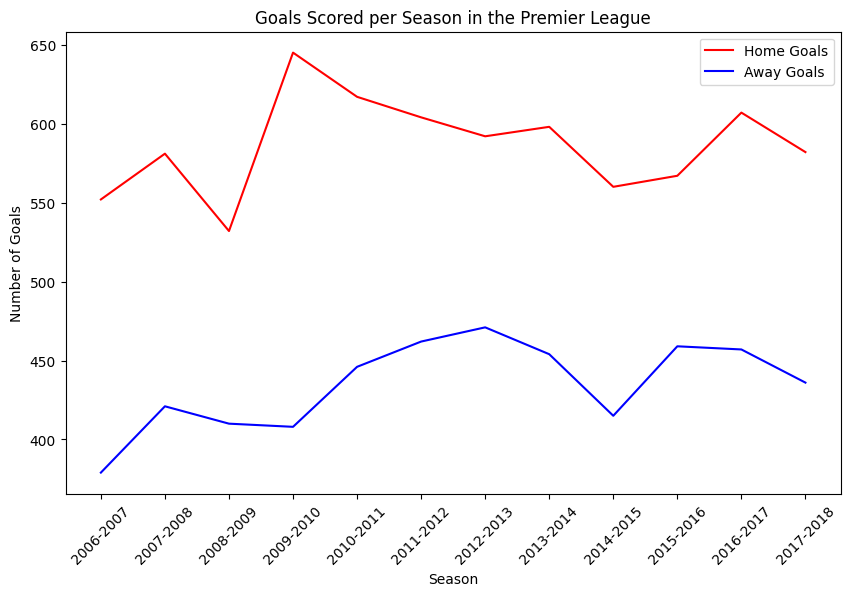

In [38]:
# Line chart of goal distribution per season

plt.figure(figsize=(10, 6))

plt.plot(
    season_goals.index,
    season_goals["home_goals"],
    color="red",
    label="Home Goals",
)

plt.plot(
    season_goals.index,
    season_goals["away_goals"],
    color="blue",
    label="Away Goals",
)

plt.title("Goals Scored per Season in the Premier League")
plt.xlabel("Season")
plt.xticks(rotation=45)
plt.ylabel("Number of Goals")

plt.legend()

